
# Comparación perturbación sintética: true vs initial vs reco

Este notebook carga la **primera tanda de 10 horas** de la inversión de la perturbación con datos sintéticos y compara:

- parámetros **true** de la perturbación,
- parámetros **initial** de la inversión,
- parámetros **reco** obtenidos por BBO,

además de reconstruir la señal **initial** con el mismo forward model y compararla con:

- `target` (señal total sintética verdadera guardada en el `.h5`),
- `reco` (señal reconstruida guardada en el `.h5`).

Las métricas usan exactamente el mismo chi² normalizado de la inversión sintética:

\[
\chi^2 = \frac{\sum (A_\mathrm{model}-A_\mathrm{target})^2}{\sum (A_\mathrm{target}-\overline{A}_\mathrm{target})^2 + 10^{-12}}
+
\frac{\sum (\phi_\mathrm{target}-\phi_\mathrm{target,mean})^2}{\sum (\phi_\mathrm{target}-\overline{\phi}_\mathrm{target})^2 + 10^{-12}}
\]

Más precisamente:

\[
\chi^2_A = \frac{\sum (A_\mathrm{model}-A_\mathrm{target})^2}{\sum (A_\mathrm{target}-\overline{A}_\mathrm{target})^2 + 10^{-12}},\qquad
\chi^2_\phi = \frac{\sum (\phi_\mathrm{target}-\phi_\mathrm{model})^2}{\sum (\phi_\mathrm{target}-\overline{\phi}_\mathrm{target})^2 + 10^{-12}}
\]

y \(\chi^2_\mathrm{tot} = \chi^2_A + \chi^2_\phi\).


In [1]:

using HDF5
using JLD2
using Dates
using TimeZones
using Statistics
using Polynomials
using CairoMakie
const CM = CairoMakie

# === Ajusta solo si cambias de archivo ===
results_h5 = "new-normalized-perturbation-synthetic-inversion_results_12343185.h5"
reference_jld2 = "reference-efield-firi.jld2"

# Parámetros "true" de la perturbación usados para crear los sintéticos
amp_true = 20.0
tau_u_true = 0.052938374 * 3600.0
tau_d_true = 0.34682182  * 3600.0
eps_true   = 0.21935698  * 3600.0
z0_true    = 85.0
hz_true    = 10.0

true_params_pert = [amp_true, tau_u_true, tau_d_true, eps_true, z0_true, hz_true]
param_names_pert = ["amp", "tau_u_s", "tau_d_s", "eps_s", "z0_km", "hz_km"]

@assert isfile(results_h5) "No existe el archivo de resultados: $results_h5"
@assert isfile(reference_jld2) "No existe el archivo de referencia: $reference_jld2"
println("Usando results_h5 = ", results_h5)


[ Info: Precompiling JLD2 [033835bb-8acc-5ee8-8aae-3f567f8a3819] (cache misses: wrong dep version loaded (4))


LoadError: AssertionError: No existe el archivo de resultados: new-normalized-perturbation-synthetic-inversion_results_12343185.h5

In [2]:

################################################################################
# Carga del entorno LMP usado por el script
################################################################################
println("[CHECK] Antes de preamble"); flush(stdout)
include("./mytools/preamble.jl")

println("[CHECK] Después de preamble"); flush(stdout)
include("./mytools/scenario.jl")

println("[CHECK] Después de scenario"); flush(stdout)

using LinearAlgebra
using AstroLib
using DSP
using Interpolations: LinearInterpolation, interpolate, extrapolate, Gridded, Linear, Line
BLAS.set_num_threads(1)


[CHECK] Antes de preamble


[ Info: Precompiling UnPackExt [54d139d9-0a94-509c-a857-5483d55ba1db] (cache misses: wrong dep version loaded (6))
[ Info: Loading CHAOS-7.11.mat


[CHECK] Después de preamble
Geodesic Distance from WWVB to PLO: 6568.28 km
Geodesic Distance from WWVB to PIU: 5659.0 km
Geodesic Distance from NAA to PLO: 6568.28 km
Geodesic Distance from NAA to PIU: 5659.0 km
Initial time: 2008-01-10T10:00:00+00:00
Scenario defined.
Datetime range: from 2008-01-10 10:00:00 UTC to 2008-01-11 10:00:00 UTC with a length of 289.
[CHECK] Después de scenario


In [3]:

################################################################################
# Utilidades del script
################################################################################
struct InversionResults
    timestamps :: Vector{Float64}
    target_A   :: Vector{Float64}
    target_phi :: Vector{Float64}
    A_reco     :: Vector{Float64}
    phi_reco   :: Vector{Float64}
    true_h     :: Vector{Float64}
    true_beta  :: Vector{Float64}
    initial_params :: Vector{Float64}
    reco_params :: Vector{Float64}
    reco_model :: String
    parameter_names :: Vector{String}
    meta       :: Dict{String,String}
end

function load_results_h5(path::AbstractString)::InversionResults
    @assert isfile(path) "No existe el archivo: $path"
    h5open(path, "r") do f
        ts   = Vector{Float64}(read(f["timestamps"]))
        tA   = Vector{Float64}(read(f["target_A"]))
        tPhi = Vector{Float64}(read(f["target_phi"]))
        rA   = Vector{Float64}(read(f["A_reco"]))
        rPhi = Vector{Float64}(read(f["phi_reco"]))
        th   = Vector{Float64}(read(f["true_h"]))
        tb   = Vector{Float64}(read(f["true_beta"]))
        ip   = haskey(f, "initial_params") ? Vector{Float64}(read(f["initial_params"])) : Float64[]
        rp   = haskey(f, "reco_params") ? Vector{Float64}(read(f["reco_params"])) : Float64[]

        meta = Dict{String,String}()
        ats = HDF5.attributes(f)
        for k in keys(ats)
            val = try
                read(ats[k])
            catch
                nothing
            end
            meta[String(k)] = string(val)
        end
        reco_model = get(meta, "reco_model", "unknown")
        parameter_names = isempty(get(meta, "parameter_names", "")) ? String[] : split(meta["parameter_names"], ",")

        return InversionResults(ts, tA, tPhi, rA, rPhi, th, tb, ip, rp, reco_model, parameter_names, meta)
    end
end

function summary(r::InversionResults)
    println("InversionResults")
    println("  N timestamps:      ", length(r.timestamps))
    println("  target_A / phi:    ", length(r.target_A), " / ", length(r.target_phi))
    println("  reco_A / phi:      ", length(r.A_reco), " / ", length(r.phi_reco))
    println("  true_h / true_beta:", length(r.true_h), " / ", length(r.true_beta))
    println("  reco_model:        ", r.reco_model)
    println("  initial_params:    ", r.initial_params)
    println("  reco_params:       ", r.reco_params)
    println("  parameter_names:   ", r.parameter_names)
    if !isempty(r.meta)
        println("  meta: ", r.meta)
    end
    nothing
end

function chi_signed_astrolib(lat_deg::Real, lon_deg::Real, zdt::ZonedDateTime;
                             height_m::Real=0.0, units::Symbol=:deg)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd  = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(ra, dec, jd, lat_deg, lon_deg, height_m)
    sza = 90.0 - alt_deg
    chi_deg = (0.0 <= az_deg < 180.0) ? -sza : +sza
    return units === :rad ? deg2rad(chi_deg) : chi_deg
end

const LinBC = Interpolations.Linear()

function unwrap_resampled(
    t_ref::Vector{ZonedDateTime}, phi_wr_ref::AbstractVector{<:Real},
    t_new::Vector{ZonedDateTime}, phi_wr_new::AbstractVector{<:Real};
    discont = 0.9*π
)
    @assert length(t_ref) == length(phi_wr_ref)
    @assert length(t_new) == length(phi_wr_new)
    @assert issorted(t_ref)
    @assert issorted(t_new)

    phi_ref_unw = DSP.unwrap(collect(float.(phi_wr_ref)); dims=1, discont=discont, period=2π)

    to_ms(zdt_vec) = Float64.(Dates.value.(DateTime.(astimezone.(zdt_vec, Ref(tz"UTC")))))
    x_ref = to_ms(t_ref)
    x_new = to_ms(t_new)

    itp_phi = LinearInterpolation(x_ref, phi_ref_unw; extrapolation_bc=LinBC)
    phi_ref_at_new = itp_phi.(x_new)

    phi_wr_new_f = collect(float.(phi_wr_new))
    phi_unw_new  = similar(phi_wr_new_f)
    @inbounds for k in eachindex(phi_wr_new_f)
        m = round((phi_ref_at_new[k] - phi_wr_new_f[k]) / (2*π))
        phi_unw_new[k] = phi_wr_new_f[k] + m*2*π
    end
    return phi_unw_new
end

Base.@kwdef struct SimCache
    tx::Any
    rx::Any
    rx_rec::Any
    ground::Any
    dists12::Vector{Float64}
    dists22::Vector{Float64}
    dt::Vector{ZonedDateTime}
    bf_list::Vector{Any}
end

function build_cache(ts, tx, rx, rx_rec, ground, dists_new)
    dt = ZonedDateTime.(unix2datetime.(ts), tz"UTC")
    d12 = dists_new[1:2:end]
    d22 = dists_new[2:2:end]
    bf_list = [igrf(tx, rx_rec, year(ti), d22; alt=60e3) for ti in dt]
    return SimCache(tx=tx, rx=rx, rx_rec=rx_rec, ground=ground,
                    dists12=d12, dists22=d22, dt=dt, bf_list=bf_list)
end

@inline nexp(z_km::Real, z0::Real, hz::Real) = exp(clamp((z_km - z0) / hz, -50.0, 50.0))

@inline function gauss_asym_F3(Δt::Real, amp::Real, t_pk::Real, τ_u::Real, τ_d::Real, eps_t::Real)
    w = τ_u + 0.5 * (τ_d - τ_u) * (1.0 + tanh((Δt - t_pk) / eps_t))
    return amp * exp(-0.5 * ((Δt - t_pk) / w)^2)
end

@inline function ne_perturb_f3(z::Real, h_i::Real, β_i::Real, Δt::Real,
                               amp::Real, t_pk::Real, τ_u::Real, τ_d::Real, eps_t::Real,
                               z0::Real, hz::Real)
    ne_bg = waitprofile(z, h_i, β_i)
    return ne_bg * (1 + nexp(z/1e3, z0, hz) * gauss_asym_F3(Δt, amp, t_pk, τ_u, τ_d, eps_t))
end

function vlfsignal_perturbation_f3(zdt_test_ref, ϕ_firi_wrapped_ref, mat_sza, pars_list,
                                   p::AbstractVector{<:Real}, t_pk_fixed::Real, cache::SimCache)
    @assert length(p) == 6 "F3+nexp requiere 6 parámetros"
    amp, τ_u, τ_d, eps_t, z0, hz = p

    p_h_sza = Polynomial(pars_list[1])
    p_β_sza = Polynomial(pars_list[2])

    Nt = length(cache.dt)
    A_fit_sfₜ = Vector{Float64}(undef, Nt)
    ϕ_fit_sfₜ = Vector{Float64}(undef, Nt)

    @inbounds for (k, tt) in enumerate(cache.dt)
        Δt = Second(tt - t₀).value
        sza_tᵢ     = mat_sza[k, :]
        rad_sza_tᵢ = (π/180.0) .* sza_tᵢ
        hs_aux     = p_h_sza.(rad_sza_tᵢ[2:2:end])
        βs_aux     = p_β_sza.(rad_sza_tᵢ[2:2:end])
        Nwaveguide = length(sza_tᵢ[2:2:end])

        bf_k = cache.bf_list[k]
        species_sf = Vector{Any}(undef, Nwaveguide)
        for i in 1:Nwaveguide
            h_i, β_i = hs_aux[i], βs_aux[i]
            f_perturb = z -> ne_perturb_f3(z, h_i, β_i, Δt, amp, t_pk_fixed, τ_u, τ_d, eps_t, z0, hz)
            species_sf[i] = Species(QE, ME, f_perturb, electroncollisionfrequency)
        end

        wg_sf = SegmentedWaveguide([
            HomogeneousWaveguide(bf_k[j], species_sf[j], cache.ground, cache.dists12[j])
            for j in 1:Nwaveguide
        ])
        _, A_fit_seg_sf, ϕ_fit_seg_sf = propagate(wg_sf, cache.tx, cache.rx)
        A_fit_sfₜ[k] = Float64(A_fit_seg_sf)
        ϕ_fit_sfₜ[k] = Float64(ϕ_fit_seg_sf)
    end

    ϕ_fit_sf_unₜ = unwrap_resampled(zdt_test_ref, ϕ_firi_wrapped_ref, cache.dt, ϕ_fit_sfₜ)
    ϕ_fit_sf_unₜ = rad2deg.(ϕ_fit_sf_unₜ)
    return A_fit_sfₜ, ϕ_fit_sf_unₜ
end

function chisq_norm(A_model, phi_model, target_A, target_phi)
    scale_A   = sum((target_A .- mean(target_A)).^2) + 1e-12
    scale_phi = sum((target_phi .- mean(target_phi)).^2) + 1e-12
    chiA = sum((A_model .- target_A).^2) / scale_A
    chiP = sum((target_phi .- phi_model).^2) / scale_phi
    return (; chiA=chiA, chiP=chiP, chiT=chiA + chiP)
end


chisq_norm (generic function with 1 method)

In [46]:

################################################################################
# Carga de resultados y de la referencia para unwrapping
################################################################################
res = load_results_h5(results_h5)
summary(res)

jldfile_ref = jldopen(reference_jld2, "r")
A_firi_ref = jldfile_ref["amp"]
phi_firi_wrapped_ref = jldfile_ref["phi"]
zdt_ref = jldfile_ref["zdt"]
close(jldfile_ref)

println("t_pk_fixed_s = ", get(res.meta, "t_pk_fixed_s", "no encontrado"))
t_pk_fixed = parse(Float64, get(res.meta, "t_pk_fixed_s", "1800.0"))

# Background usado en la inversión de perturbación
coeffs_h_bg = collect(Float64.(res.true_h))
coeffs_beta_bg = collect(Float64.(res.true_beta))
pars_list_bg = [coeffs_h_bg, coeffs_beta_bg]

# Parámetros de perturbación
initial_params = collect(Float64.(res.initial_params))
reco_params    = collect(Float64.(res.reco_params))

@assert length(initial_params) == 6
@assert length(reco_params) == 6
@assert length(true_params_pert) == 6


InversionResults
  N timestamps:      17
  target_A / phi:    17 / 17
  reco_A / phi:      17 / 17
  true_h / true_beta:9 / 6
  reco_model:        F3_gaussiana_asimetrica_nexp_vertical_tpk_fijo_synthetic_bg_from_h5
  initial_params:    [19.6, 186.766583472, 1223.58738096, 773.89142544, 83.3, 9.8]
  reco_params:       [19.369055663934706, 188.8266333492869, 1216.6673834663172, 786.276007829002, 84.684357789662, 9.592799032392989]
  parameter_names:   ["amp", "tau_u_s", "tau_d_s", "eps_s", "z0_km", "hz_km"]
  meta: Dict("t_pk_fixed_s" => "1800.0", "parameter_names" => "amp,tau_u_s,tau_d_s,eps_s,z0_km,hz_km", "reco_model" => "F3_gaussiana_asimetrica_nexp_vertical_tpk_fijo_synthetic_bg_from_h5")
t_pk_fixed_s = 1800.0


In [45]:

################################################################################
# Reconstrucción de la malla temporal y geométrica usada en la inversión
################################################################################
z = collect(alt) / 1e3
t_step = Minute(5)
zdt0 = ZonedDateTime(2008, 3, 25, 18, 0, 0, tz"UTC")
zdt = datelinspace(zdt0, zdt0 + Hour(4), t_step)

npoints = 19
lats_new, lons_new, dists_new = geolinspace("NAA", "PLO", npoints, false)
lon_rx, lat_rx = rx_params["Longitude"], rx_params["Latitude"]
rx_rec = Receiver("PLO", lat_rx, lon_rx, 0.0, VerticalDipole())

zdt_test = zdt[1:3:end]
timestamps_test = datetime2unix.(DateTime.(zdt_test))
@assert length(timestamps_test) == length(res.timestamps)
@assert all(isapprox.(timestamps_test, res.timestamps; atol=0.5))

mat_sza = Matrix{Float64}(undef, length(zdt_test), length(dists_new))
for (k, tt) in enumerate(zdt_test)
    mat_sza[k, :] = chi_signed_astrolib.(lats_new, lons_new, tt)
end

t₀ = ZonedDateTime(2008, 3, 25, 18, 30, 0, tz"UTC")
CACHE = build_cache(res.timestamps, tx2, rx, rx_rec, ground, dists_new)

println("Number of waveguide segments: ", length(lats_new[2:2:end]))
println("N tiempos = ", length(zdt_test))


Number of waveguide segments: 10
N tiempos = 17


In [15]:

################################################################################
# Reconstrucción de la señal inicial y métricas
################################################################################
target_A = collect(Float64.(res.target_A))
target_phi = collect(Float64.(res.target_phi))

A_init, phi_init = vlfsignal_perturbation_f3(zdt_ref, phi_firi_wrapped_ref, mat_sza,
                                             pars_list_bg, initial_params, t_pk_fixed, CACHE)

m_init = chisq_norm(A_init, phi_init, target_A, target_phi)
m_reco = chisq_norm(res.A_reco, res.phi_reco, target_A, target_phi)

println("Initial χ²_A   = ", m_init.chiA)
println("Initial χ²_phi = ", m_init.chiP)
println("Initial χ²_tot = ", m_init.chiT)
println()
println("Reco χ²_A   = ", m_reco.chiA)
println("Reco χ²_phi = ", m_reco.chiP)
println("Reco χ²_tot = ", m_reco.chiT)


Initial χ²_A   = 0.019784649027927082
Initial χ²_phi = 0.027312231301532718
Initial χ²_tot = 0.0470968803294598

Reco χ²_A   = 0.01633147328650871
Reco χ²_phi = 0.018580496941714732
Reco χ²_tot = 0.03491197022822344


In [16]:

################################################################################
# Tablas resumen
################################################################################
using DataFrames

df_params = DataFrame(
    parameter = param_names_pert,
    true = true_params_pert,
    initial = initial_params,
    reco = reco_params,
)
df_params.abs_err_init = abs.(df_params.initial .- df_params.true)
df_params.abs_err_reco = abs.(df_params.reco .- df_params.true)
df_params.rel_err_init_pct = 100 .* df_params.abs_err_init ./ abs.(df_params.true)
df_params.rel_err_reco_pct = 100 .* df_params.abs_err_reco ./ abs.(df_params.true)

df_summary = DataFrame(
    solution = ["initial", "reco"],
    chi2_A = [m_init.chiA, m_reco.chiA],
    chi2_phi = [m_init.chiP, m_reco.chiP],
    chi2_total = [m_init.chiT, m_reco.chiT],
    rmse_params_vs_true = [
        sqrt(mean((initial_params .- true_params_pert).^2)),
        sqrt(mean((reco_params .- true_params_pert).^2))
    ]
)

display(df_params)
display(df_summary)


LoadError: syntax: invalid keyword argument name "true" around In[16]:7

In [17]:

################################################################################
# Estilo CairoMakie
################################################################################
set_theme!(Theme(
    fontsize = 22,
    Axis = (
        titlesize = 26,
        xlabelsize = 24,
        ylabelsize = 24,
        xticklabelsize = 20,
        yticklabelsize = 20,
        titlecolor = :black,
        xlabelcolor = :black,
        ylabelcolor = :black,
        xtickcolor = :black,
        ytickcolor = :black,
        xticklabelcolor = :black,
        yticklabelcolor = :black,
        xgridcolor = RGBAf(0,0,0,0.15),
        ygridcolor = RGBAf(0,0,0,0.15),
        backgroundcolor = :white
    ),
    Legend = (
        labelsize = 18,
        titlesize = 18,
        framevisible = true,
        backgroundcolor = :white
    )
))


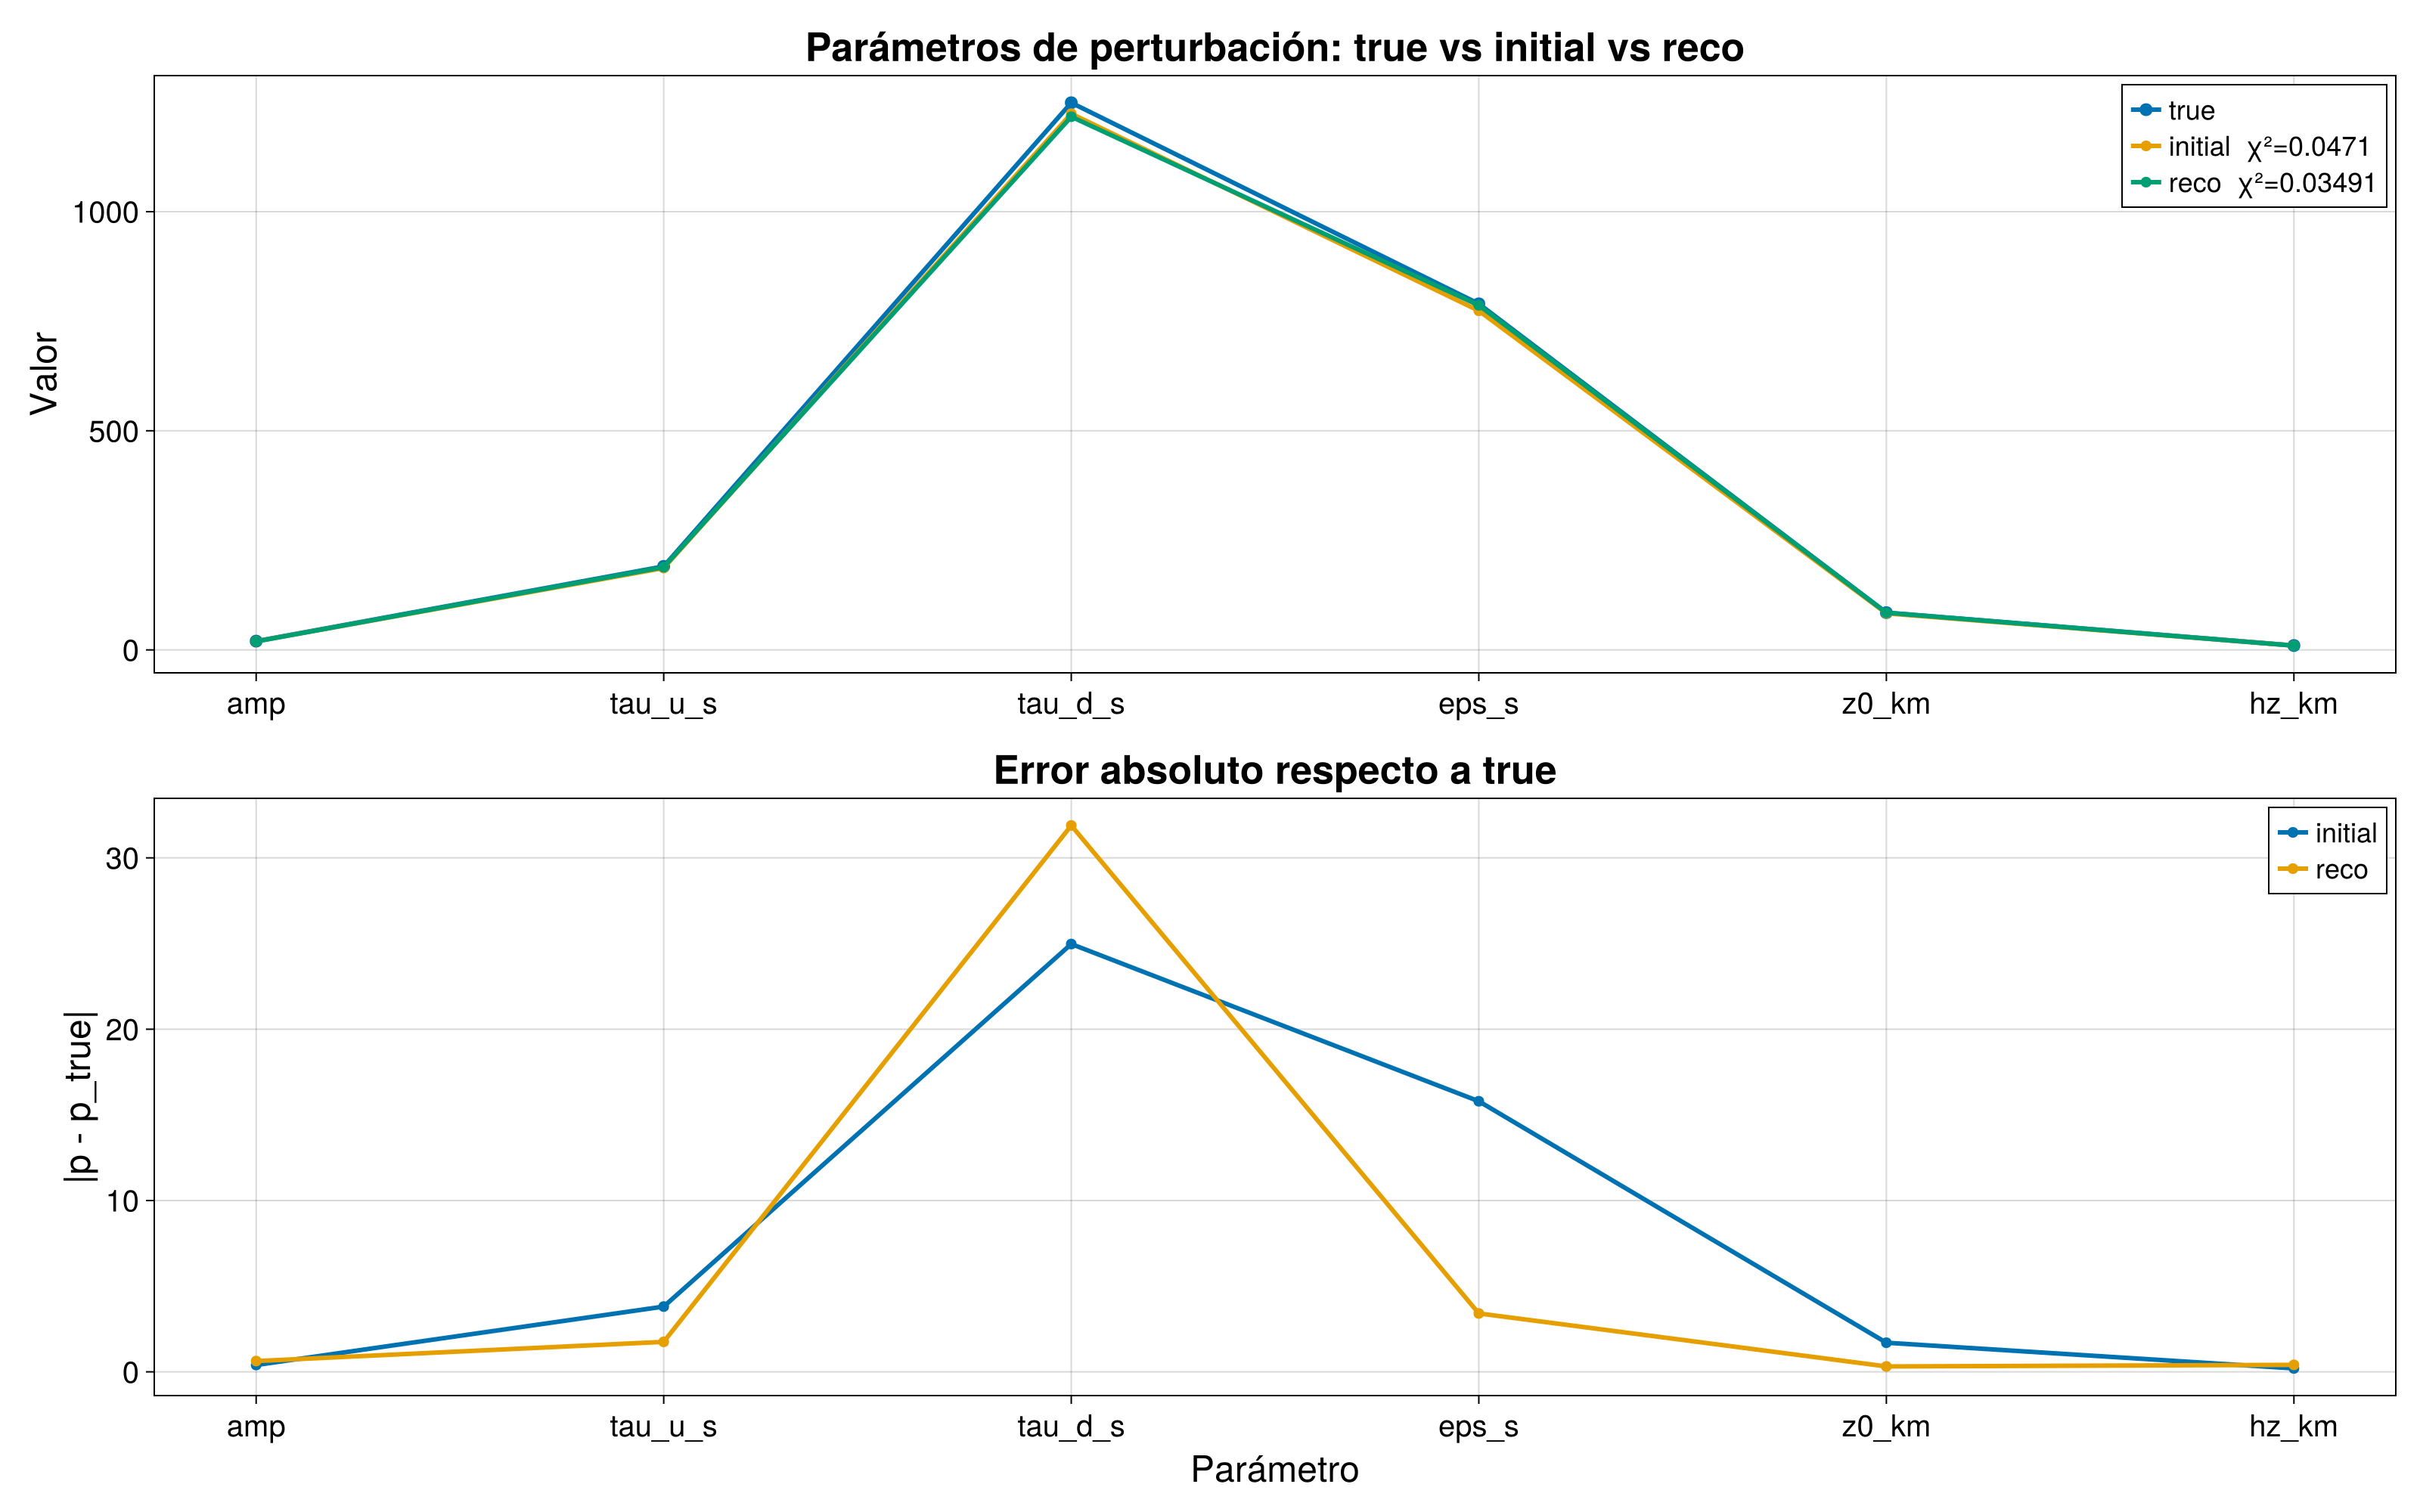

In [22]:

################################################################################
# Figura 1: comparación de parámetros
################################################################################
x = 1:length(param_names_pert)

figp = Figure(size = (1600, 1000))

ax1 = Axis(figp[1, 1],
    title = "Parámetros de perturbación: true vs initial vs reco",
    ylabel = "Valor",
    xticks = (x, param_names_pert)
)

scatterlines!(ax1, x, true_params_pert, markersize=12, linewidth=3, label="true")
scatterlines!(ax1, x, initial_params, markersize=10, linewidth=3,
    label="initial  χ²=$(round(m_init.chiT, digits=5))")
scatterlines!(ax1, x, reco_params, markersize=10, linewidth=3,
    label="reco  χ²=$(round(m_reco.chiT, digits=5))")

axislegend(ax1, position=:rt)

ax2 = Axis(figp[2, 1],
    title = "Error absoluto respecto a true",
    ylabel = "|p - p_true|",
    xlabel = "Parámetro",
    xticks = (x, param_names_pert)
)

scatterlines!(ax2, x, abs.(initial_params .- true_params_pert), markersize=10, linewidth=3,
    label="initial")
scatterlines!(ax2, x, abs.(reco_params .- true_params_pert), markersize=10, linewidth=3,
    label="reco")
axislegend(ax2, position=:rt)

figp
#save("perturbation_first_batch_params.png", figp)


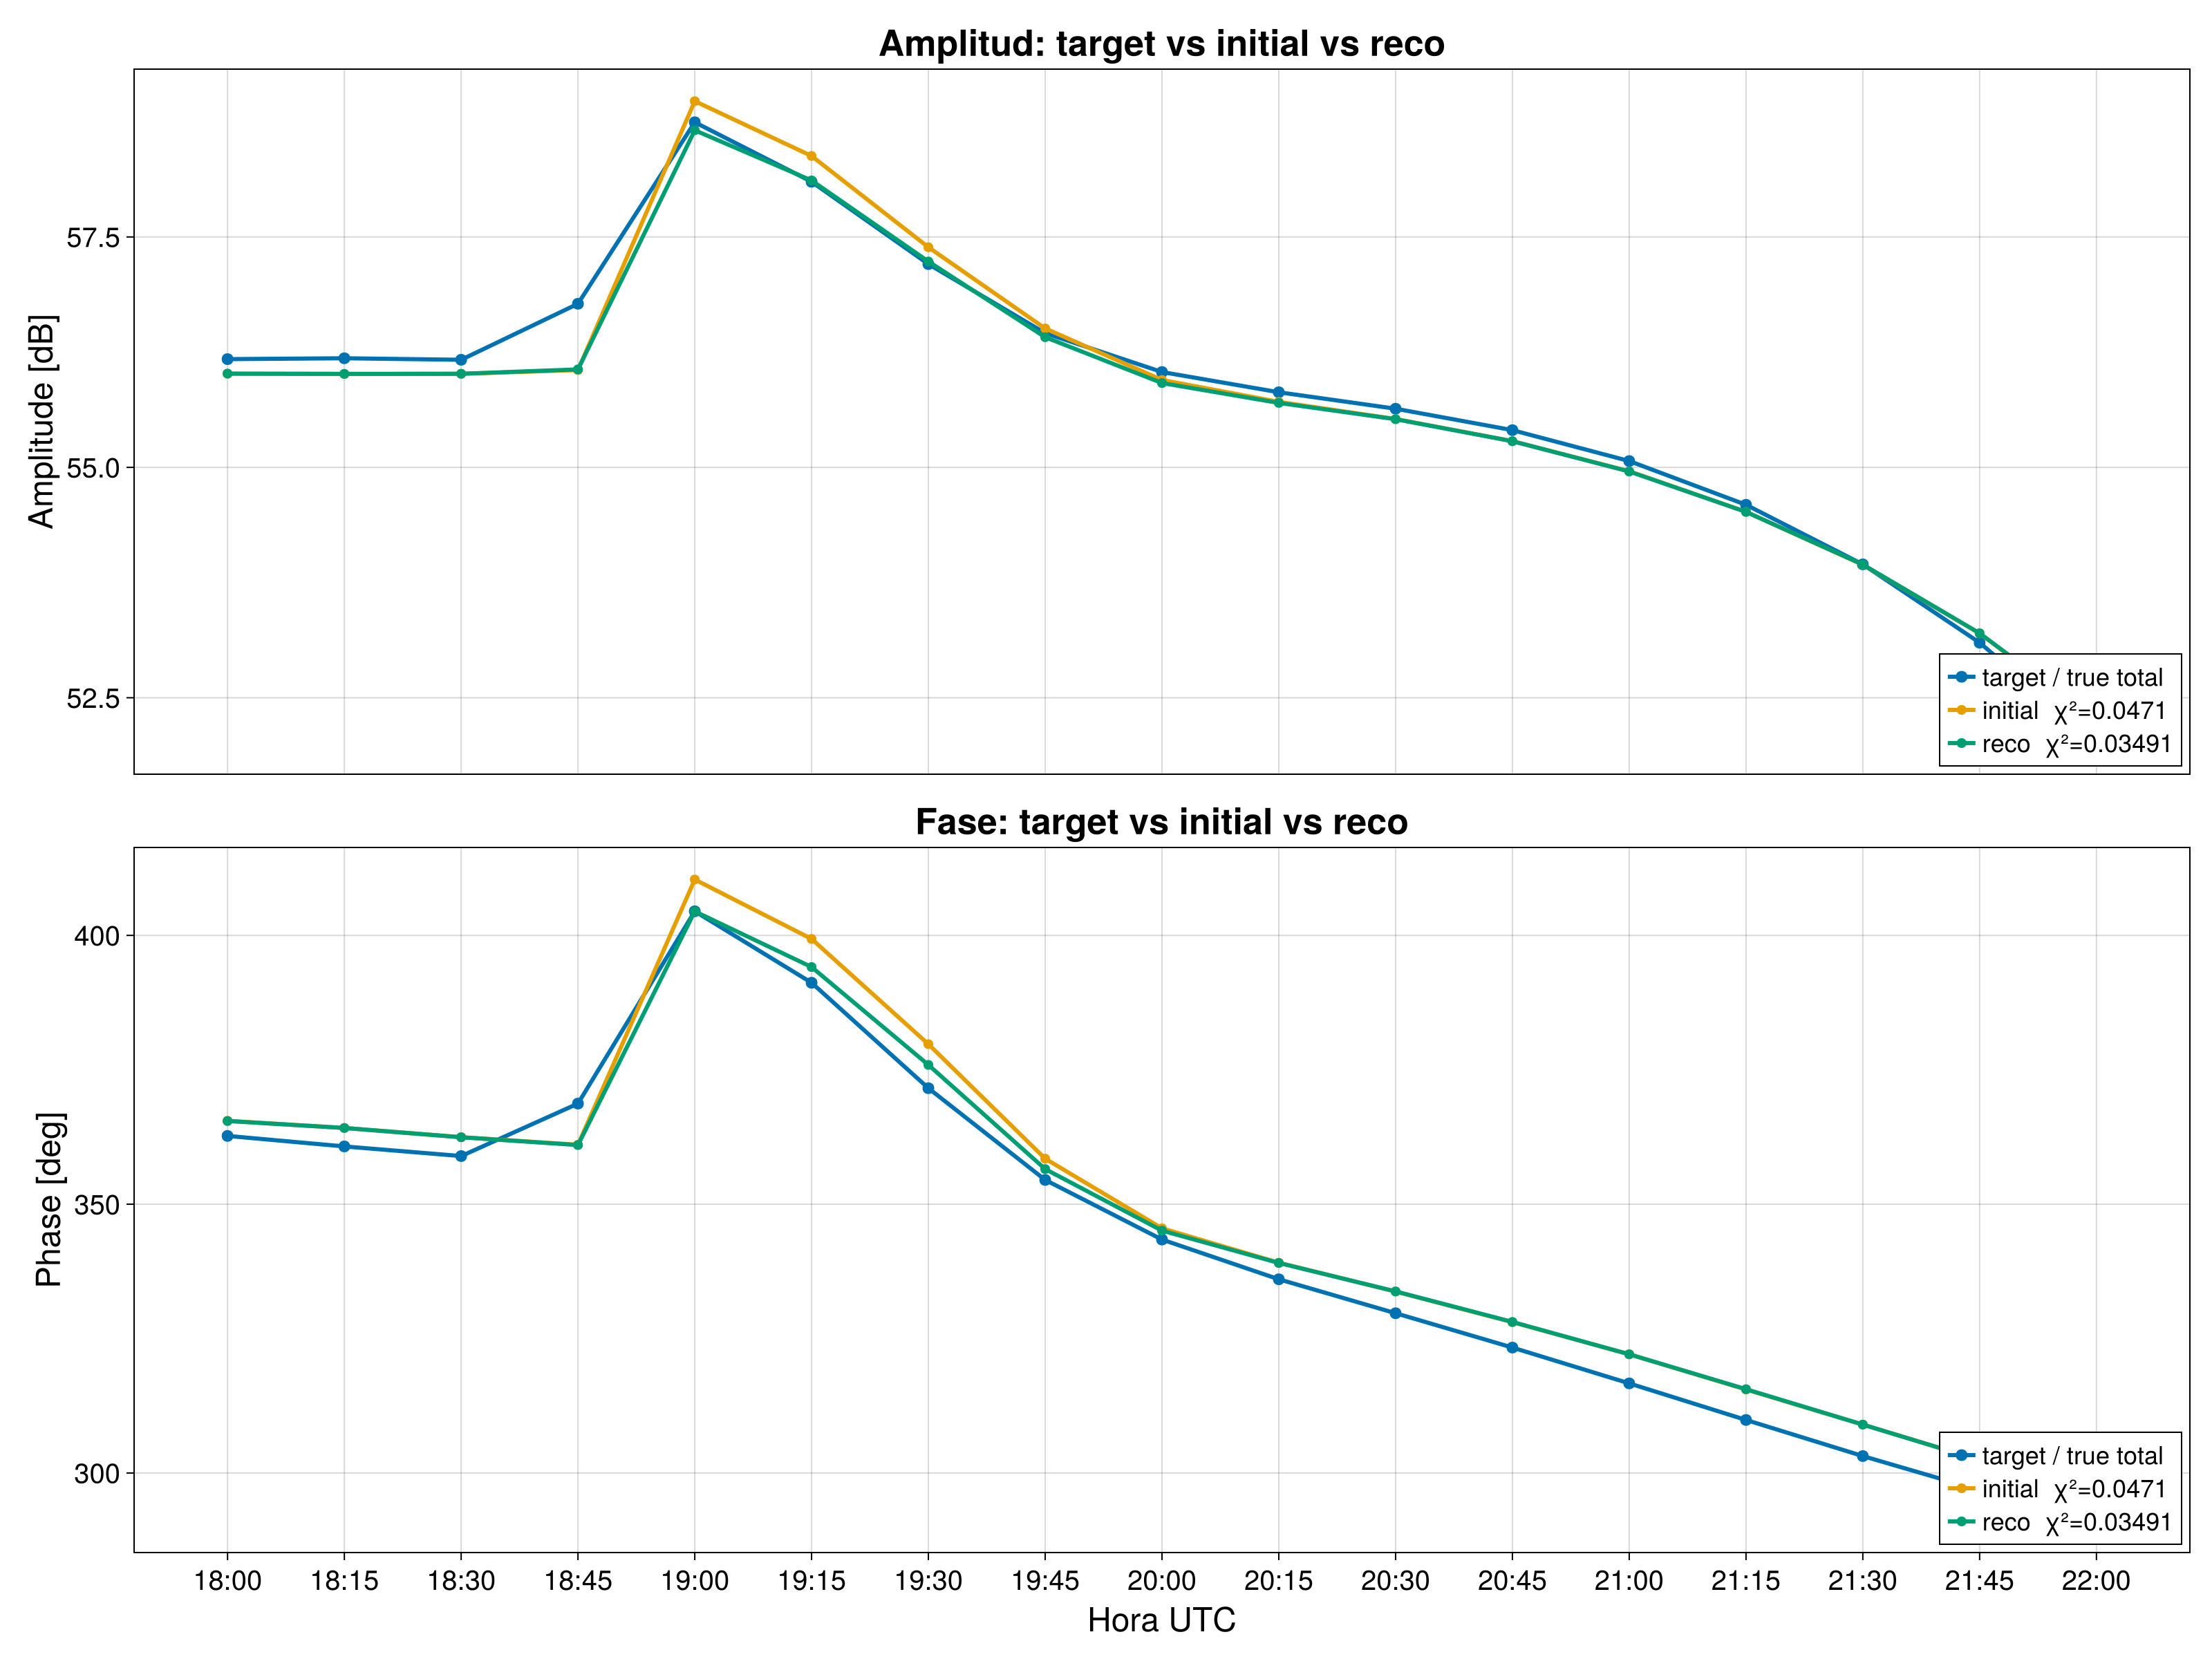

In [23]:

################################################################################
# Figura 2: series temporales
################################################################################
t0 = zdt_test[1]
time_hours = (datetime2unix.(DateTime.(zdt_test)) .- datetime2unix(DateTime(t0))) ./ 3600.0
xticks_numeric = time_hours
xtick_labels = Dates.format.(DateTime.(zdt_test), "HH:MM")

lab_target = "target / true total"
lab_init = "initial  χ²=$(round(m_init.chiT, digits=5))"
lab_reco = "reco  χ²=$(round(m_reco.chiT, digits=5))"

figts = Figure(size = (1600, 1200))

axA = Axis(
    figts[1, 1],
    title = "Amplitud: target vs initial vs reco",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

scatterlines!(axA, time_hours, target_A, markersize=12, linewidth=3, label=lab_target)
scatterlines!(axA, time_hours, A_init, markersize=10, linewidth=3, label=lab_init)
scatterlines!(axA, time_hours, res.A_reco, markersize=10, linewidth=3, label=lab_reco)
axislegend(axA, position=:rb)

axP = Axis(
    figts[2, 1],
    title = "Fase: target vs initial vs reco",
    xlabel = "Hora UTC",
    ylabel = "Phase [deg]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

scatterlines!(axP, time_hours, target_phi, markersize=12, linewidth=3, label=lab_target)
scatterlines!(axP, time_hours, phi_init, markersize=10, linewidth=3, label=lab_init)
scatterlines!(axP, time_hours, res.phi_reco, markersize=10, linewidth=3, label=lab_reco)
axislegend(axP, position=:rb)

linkxaxes!(axA, axP)

figts
#save("perturbation_first_batch_timeseries.png", figts)


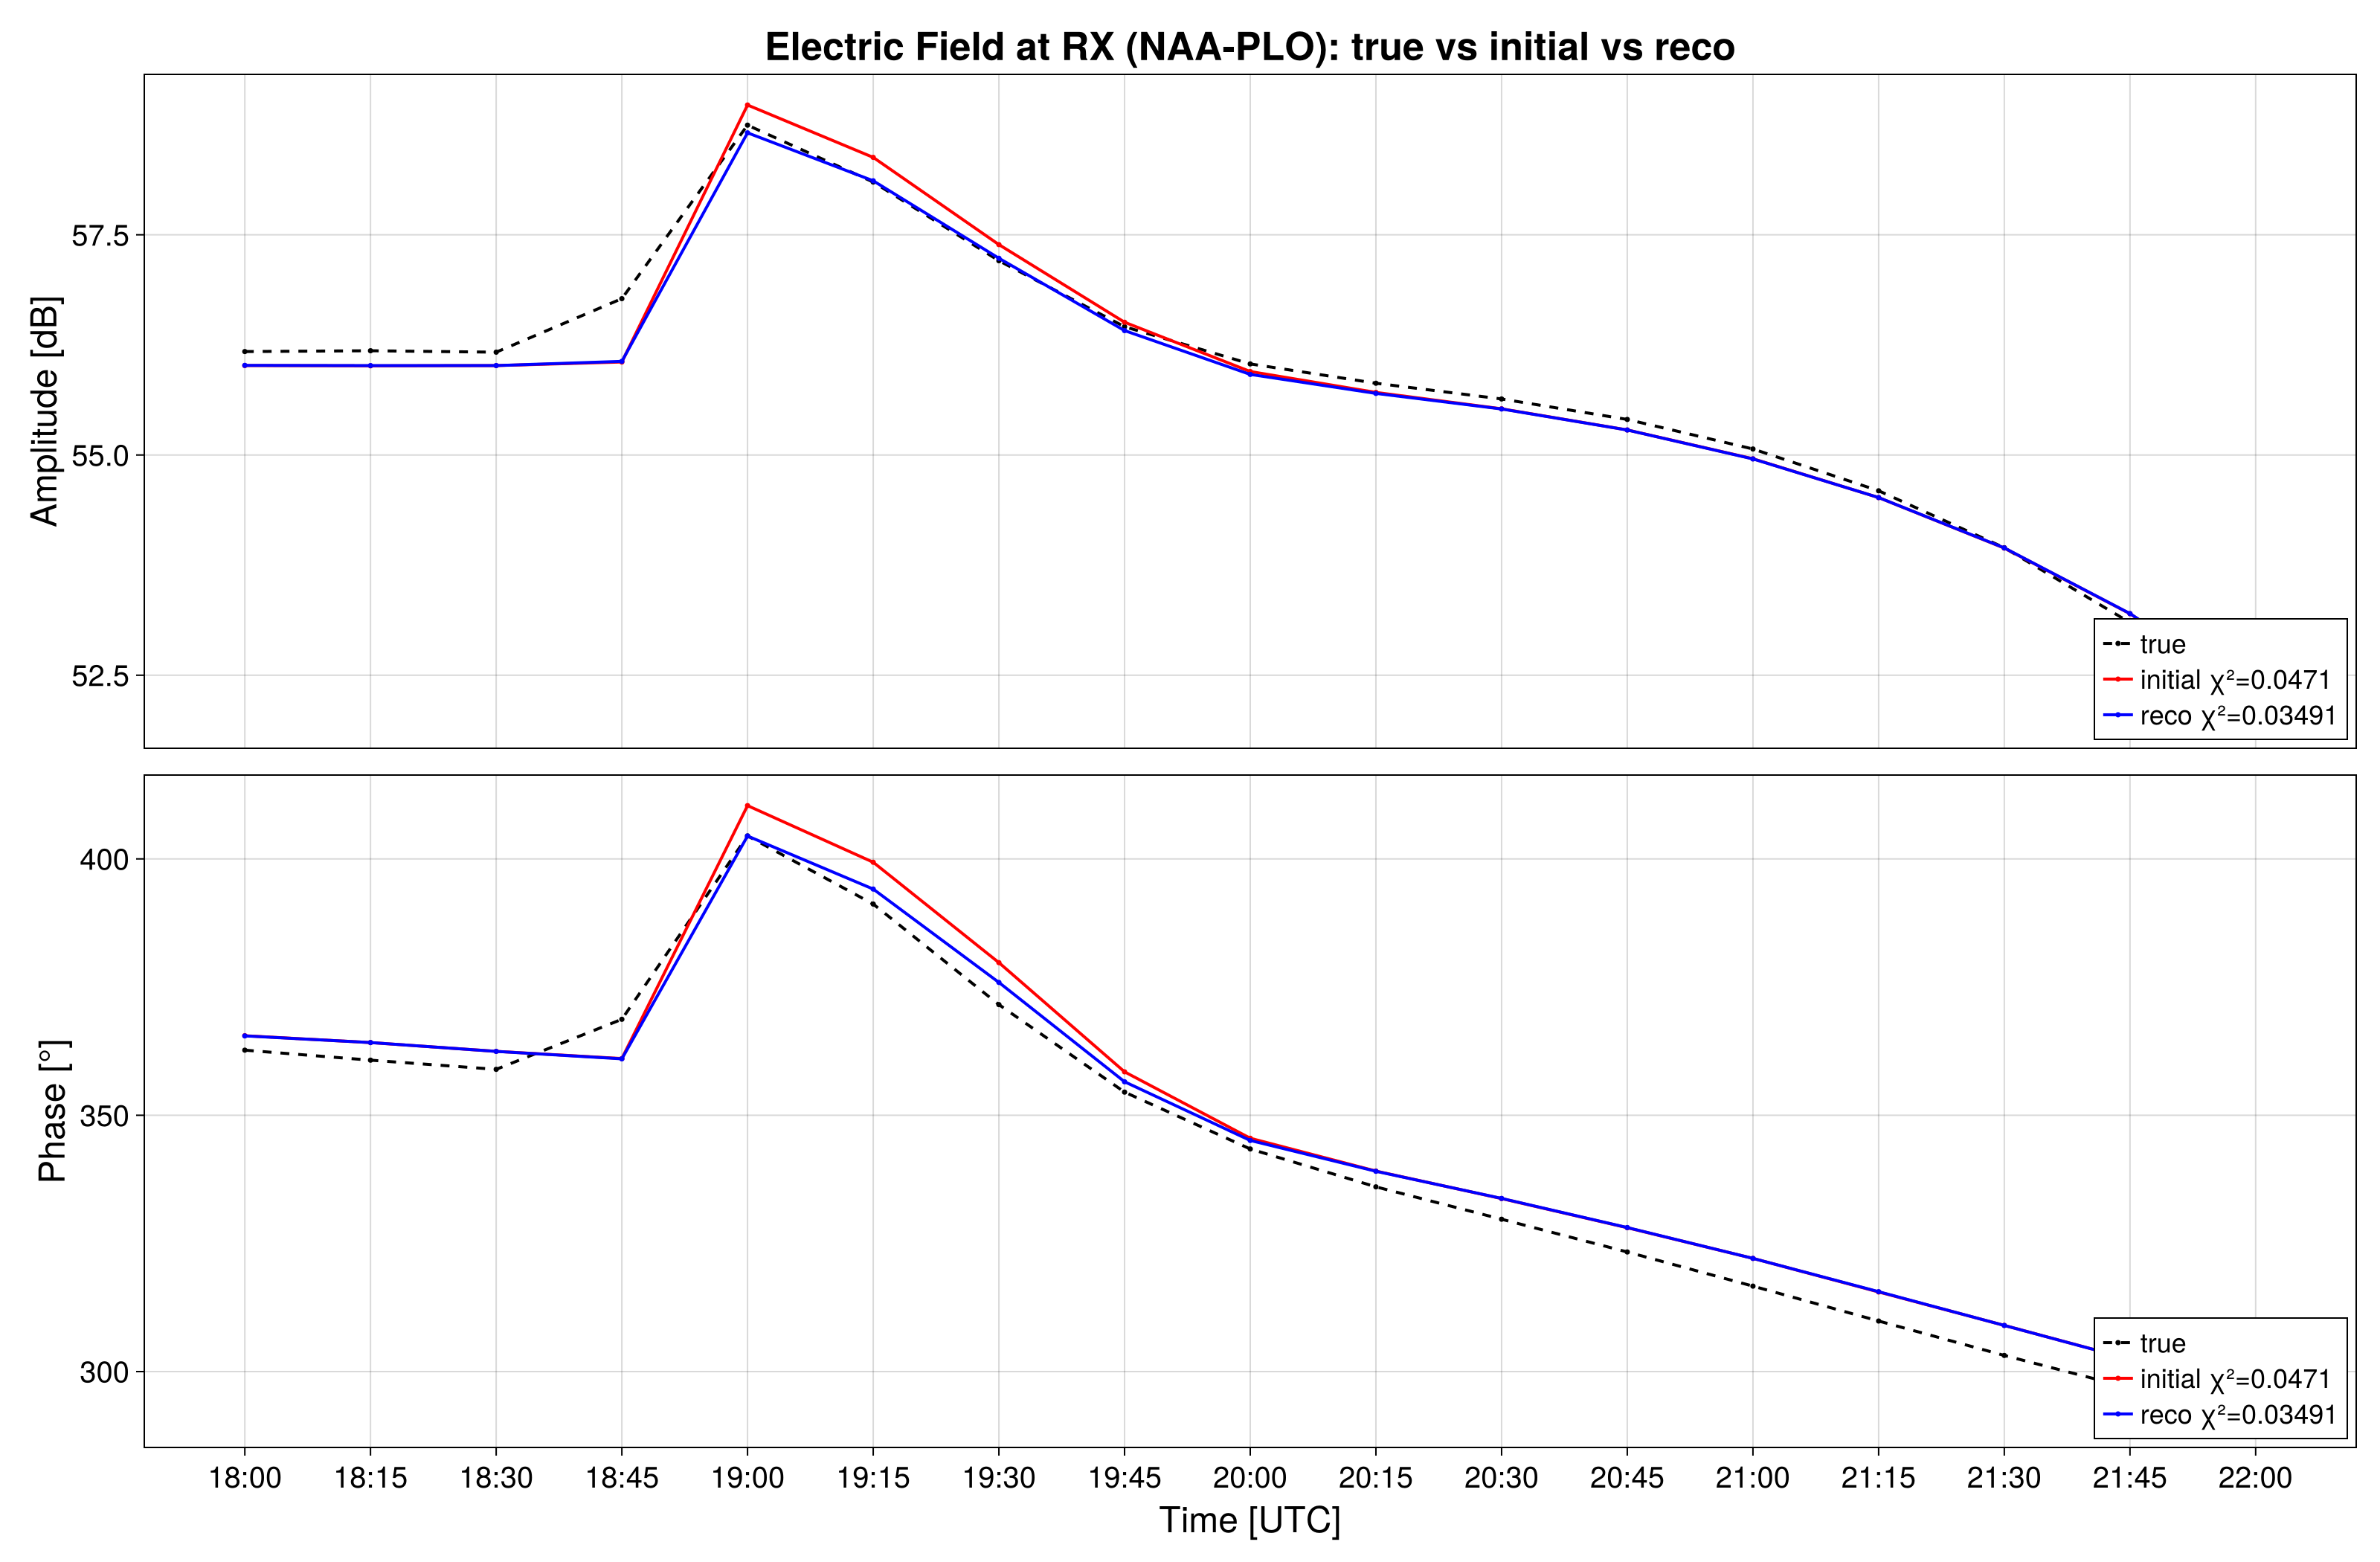

In [26]:
################################################################################
# Figura 2: series temporales
################################################################################
t0 = zdt_test[1]
time_hours = (datetime2unix.(DateTime.(zdt_test)) .- datetime2unix(DateTime(t0))) ./ 3600.0
xticks_numeric = time_hours
xtick_labels = Dates.format.(DateTime.(zdt_test), "HH:MM")

lab_target = "true"
lab_init   = "initial χ²=$(round(m_init.chiT, digits=5))"
lab_reco   = "reco χ²=$(round(m_reco.chiT, digits=5))"

MS = 5
LW = 2

figts = Figure(size = (1600, 1050), backgroundcolor = :white)

axA = Axis(
    figts[1, 1],
    title = "Electric Field at RX (NAA-PLO): true vs initial vs reco",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = π/4,
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

scatterlines!(
    axA, time_hours, target_A;
    markersize = MS, linewidth = LW,
    label = lab_target, color = :black, linestyle = :dash
)
scatterlines!(
    axA, time_hours, A_init;
    markersize = MS, linewidth = LW,
    label = lab_init, color = :red
)
scatterlines!(
    axA, time_hours, res.A_reco;
    markersize = MS, linewidth = LW,
    label = lab_reco, color = :blue
)
axislegend(axA, position = :rb)

axP = Axis(
    figts[2, 1],
    title = "",
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

scatterlines!(
    axP, time_hours, target_phi;
    markersize = MS, linewidth = LW,
    label = lab_target, color = :black, linestyle = :dash
)
scatterlines!(
    axP, time_hours, phi_init;
    markersize = MS, linewidth = LW,
    label = lab_init, color = :red
)
scatterlines!(
    axP, time_hours, res.phi_reco;
    markersize = MS, linewidth = LW,
    label = lab_reco, color = :blue
)
axislegend(axP, position = :rb)

linkxaxes!(axA, axP)

figts
# save("perturbation_first_batch_timeseries.png", figts)


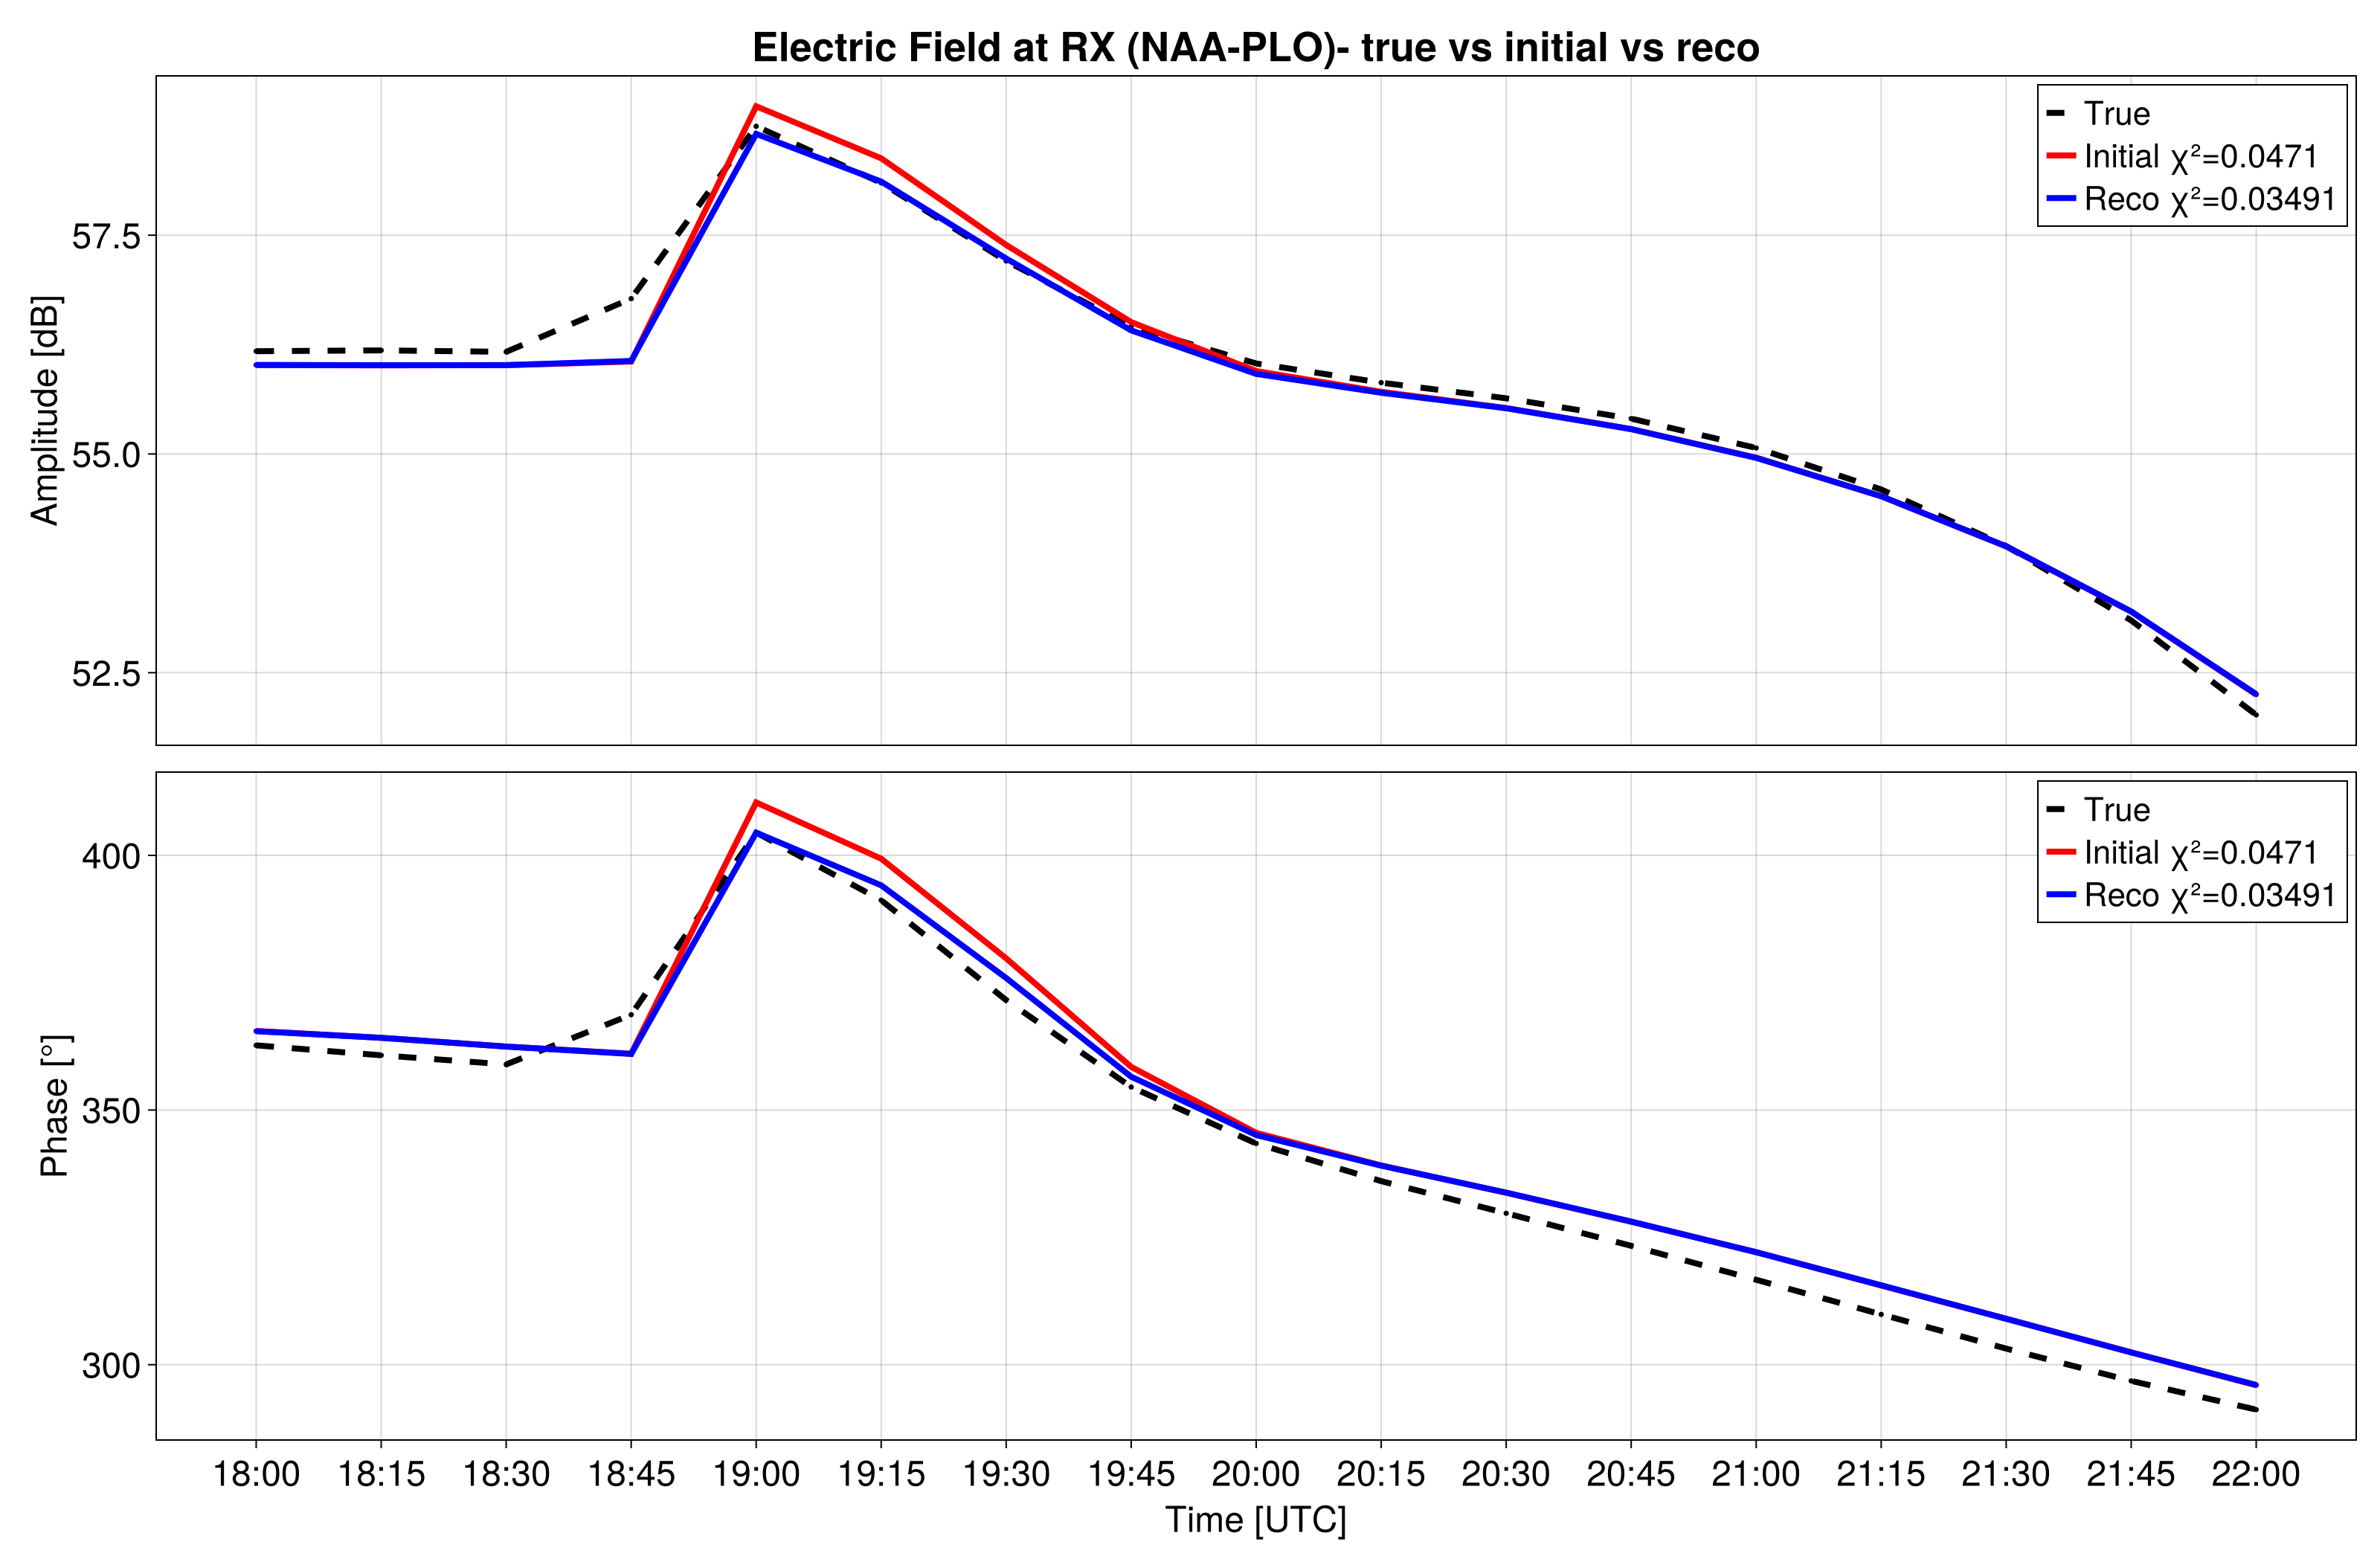

In [42]:
CairoMakie.activate!()

# Estética de alto contraste (igual al ejemplo)
#const FS_TICK   = 20
#const FS_LABEL  = 24
#const FS_TITLE  = 26
#const FS_LEGEND = 18
#const LW        = 3
#const MS        = 10
#=
set_theme!(
    fontsize = FS_LABEL,
    Axis = (
        xticklabelsize = FS_TICK,
        yticklabelsize = FS_TICK,
        xlabelsize = FS_LABEL,
        ylabelsize = FS_LABEL,
        titlesize = FS_TITLE,
        titlefont = :bold,
        xgridvisible = true,
        ygridvisible = true,
        xgridcolor = (:gray, 0.35),
        ygridcolor = (:gray, 0.35),
        leftspinecolor = :black,
        rightspinecolor = :black,
        topspinecolor = :black,
        bottomspinecolor = :black,
        xtickcolor = :black,
        ytickcolor = :black,
    ),
    Legend = (
        labelsize = FS_LEGEND,
        framevisible = true,
        framecolor = :black,
        backgroundcolor = (:white, 0.92),
    )
)
=#
################################################################################
# Figura 2: series temporales
################################################################################
ms = 5
lw = 4
fontsize = 24
t0 = zdt_test[1]
time_hours = (datetime2unix.(DateTime.(zdt_test)) .- datetime2unix(DateTime(t0))) ./ 3600.0
xticks_numeric = time_hours
xtick_labels = Dates.format.(DateTime.(zdt_test), "HH:MM")

lab_true = "True"
lab_init = "Initial χ²=$(round(m_init.chiT, digits=5))"
lab_reco = "Reco χ²=$(round(m_reco.chiT, digits=5))"

figts = Figure(size=(1600, 1050), backgroundcolor=:white)

axA = Axis(
    figts[1, 1],
    title = "Electric Field at RX (NAA-PLO)- true vs initial vs reco",
    ylabel = "Amplitude [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false,
    xlabelsize = fontsize,
    ylabelsize = fontsize,
    xticklabelsize = fontsize,
    yticklabelsize = fontsize,
    titlesize = fontsize + 3,
    titlefont = :bold,

)

scatterlines!(axA, time_hours, target_A,
    markersize=ms, linewidth=lw,
    label=lab_true, color=:black, linestyle=:dash
)
scatterlines!(axA, time_hours, A_init,
    markersize=ms, linewidth=lw,
    label=lab_init, color=:red
)
scatterlines!(axA, time_hours, res.A_reco,
    markersize=ms, linewidth=lw,
    label=lab_reco, color=:blue
)
axislegend(axA, position=:rt, labelsize=22)

axP = Axis(
    figts[2, 1],
    xlabel = "Time [UTC]",
    ylabel = "Phase [°]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0,
    xlabelsize = fontsize,
    xticklabelsize = fontsize,
    yticklabelsize = fontsize,
    ylabelsize = fontsize,
    titlesize = fontsize + 3,
    titlefont = :bold,

)

scatterlines!(axP, time_hours, target_phi,
    markersize=ms, linewidth=lw,
    label=lab_true, color=:black, linestyle=:dash
)
scatterlines!(axP, time_hours, phi_init,
    markersize=ms, linewidth=lw,
    label=lab_init, color=:red
)
scatterlines!(axP, time_hours, res.phi_reco,
    markersize=ms, linewidth=lw,
    label=lab_reco, color=:blue
)
axislegend(axP, position=:rt, labelsize=22)

linkxaxes!(axA, axP)
save("perturbation-first-batch-timeseries.pdf", figts)
figts
# 

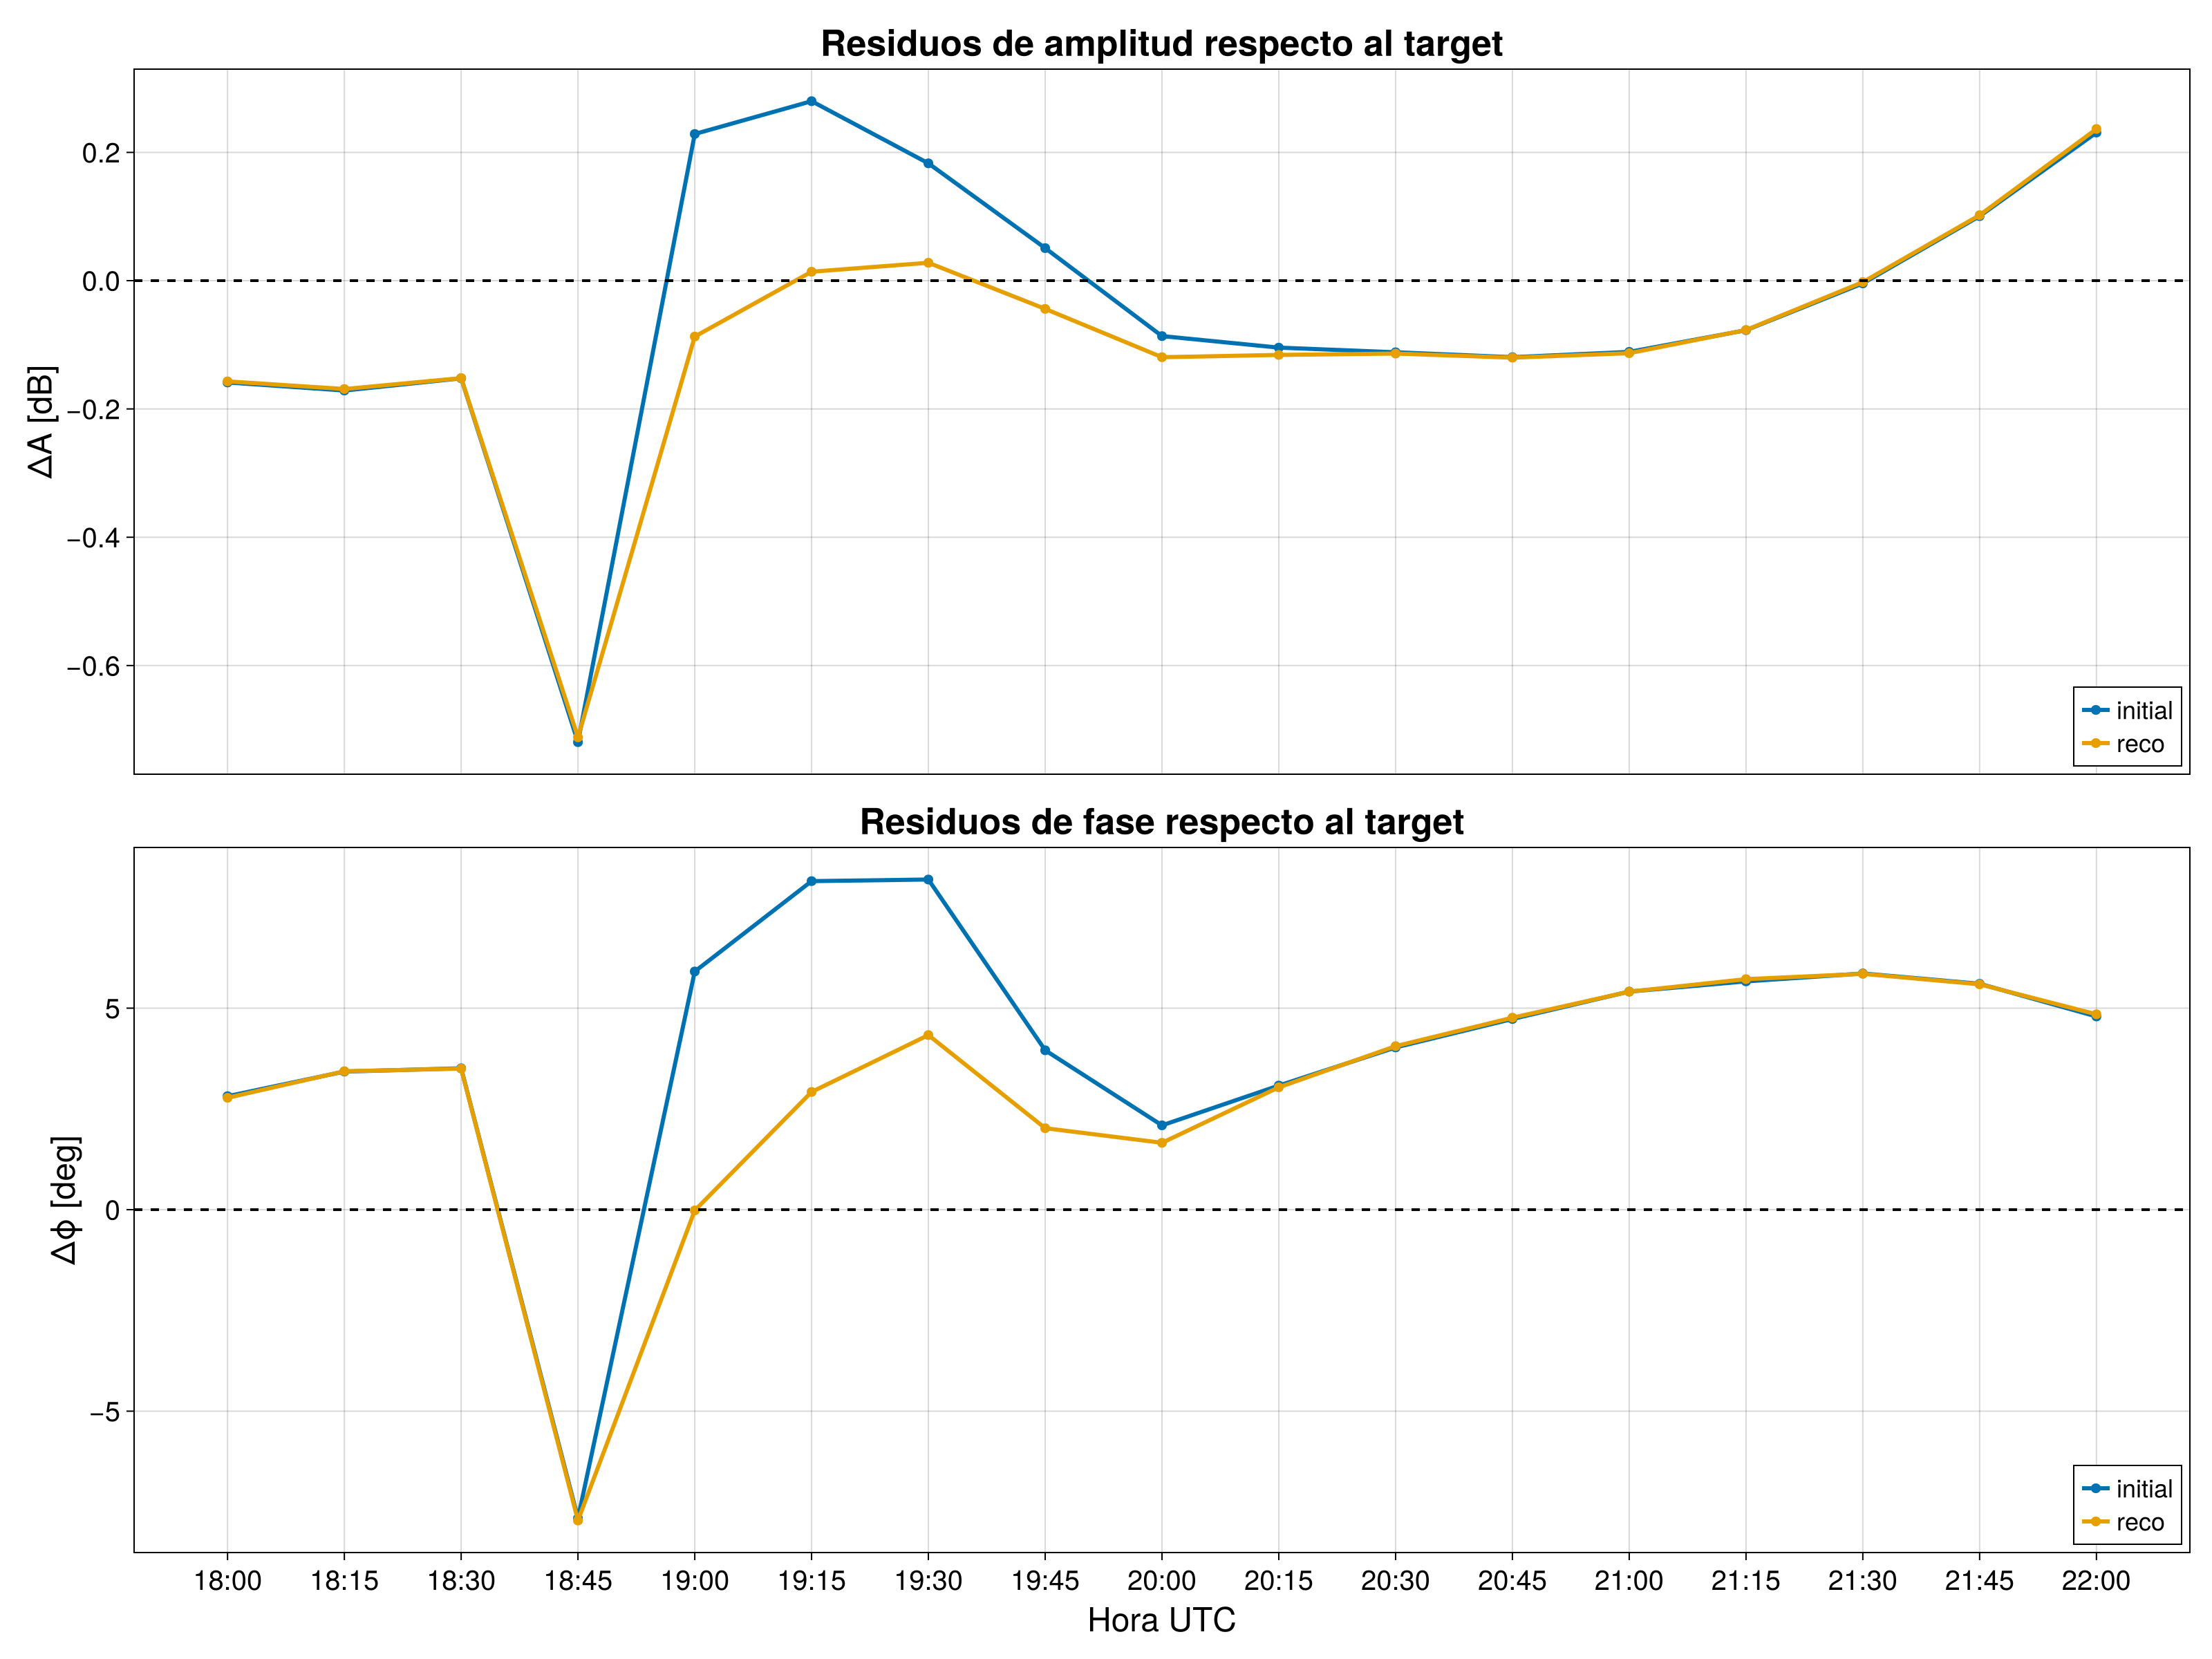

In [24]:

################################################################################
# Figura 3: residuos respecto al target
################################################################################
resA_init = A_init .- target_A
resA_reco = res.A_reco .- target_A
resP_init = phi_init .- target_phi
resP_reco = res.phi_reco .- target_phi

figr = Figure(size = (1600, 1200))

axR1 = Axis(
    figr[1, 1],
    title = "Residuos de amplitud respecto al target",
    ylabel = "ΔA [dB]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelsvisible = false,
    xticksvisible = false,
    xlabelvisible = false
)

scatterlines!(axR1, time_hours, resA_init, markersize=10, linewidth=3, label="initial")
scatterlines!(axR1, time_hours, resA_reco, markersize=10, linewidth=3, label="reco")
hlines!(axR1, [0.0], linestyle=:dash, linewidth=2, color=:black)
axislegend(axR1, position=:rb)

axR2 = Axis(
    figr[2, 1],
    title = "Residuos de fase respecto al target",
    xlabel = "Hora UTC",
    ylabel = "Δϕ [deg]",
    xticks = (xticks_numeric, xtick_labels),
    xticklabelrotation = 0
)

scatterlines!(axR2, time_hours, resP_init, markersize=10, linewidth=3, label="initial")
scatterlines!(axR2, time_hours, resP_reco, markersize=10, linewidth=3, label="reco")
hlines!(axR2, [0.0], linestyle=:dash, linewidth=2, color=:black)
axislegend(axR2, position=:rb)

linkxaxes!(axR1, axR2)

figr
#save("perturbation_first_batch_residuals.png", figr)


In [21]:

################################################################################
# Conclusión automática
################################################################################
println("\n================== CONCLUSIÓN AUTOMÁTICA ==================\n")

println("χ² inicial total = ", round(m_init.chiT, digits=6))
println("χ² reco total    = ", round(m_reco.chiT, digits=6))
println("Mejora relativa  = ", round(100 * (1 - m_reco.chiT / m_init.chiT), digits=3), " %")

rmse_init = sqrt(mean((initial_params .- true_params_pert).^2))
rmse_reco = sqrt(mean((reco_params .- true_params_pert).^2))
println("RMSE parámetros vs true (initial) = ", rmse_init)
println("RMSE parámetros vs true (reco)    = ", rmse_reco)

n_better = sum(abs.(reco_params .- true_params_pert) .< abs.(initial_params .- true_params_pert))
println("Parámetros individuales que mejoran vs initial: ", n_better, " / ", length(true_params_pert))

if m_reco.chiT < m_init.chiT
    println("\nResultado: la solución reconstruida mejora al punto inicial en la función de costo.")
else
    println("\nResultado: la solución reconstruida NO mejora al punto inicial en la función de costo.")
end

if rmse_reco < rmse_init
    println("Además, la solución reconstruida queda globalmente más cerca de los true.")
else
    println("Aunque mejora la señal, globalmente NO queda más cerca de los true.")
end



================== CONCLUSIÓN AUTOMÁTICA ==================

χ² inicial total = 0.047097
χ² reco total    = 0.034912
Mejora relativa  = 25.872 %
RMSE parámetros vs true (initial) = 12.183448031494667
RMSE parámetros vs true (reco)    = 13.117418839969115
Parámetros individuales que mejoran vs initial: 3 / 6

Resultado: la solución reconstruida mejora al punto inicial en la función de costo.
Aunque mejora la señal, globalmente NO queda más cerca de los true.
